# 01 — Exploratory Data Analysis

**Telco Customer Churn — IBM / Kaggle**  
Goal: understand the data, flag issues, and produce a data readiness verdict before modelling.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from nn_churn_prediction_fiap.config import RANDOM_STATE, TARGET_COL
from nn_churn_prediction_fiap.data.load import load_raw

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = load_raw()

{"ts": "2026-05-16T12:24:10", "level": "INFO", "logger": "nn_churn_prediction_fiap.data.load", "message": "schema validation passed", "rows": 7043, "cols": 21}
{"ts": "2026-05-16T12:24:10", "level": "INFO", "logger": "nn_churn_prediction_fiap.data.load", "message": "dropping rows with unparseable TotalCharges", "n": 11}
{"ts": "2026-05-16T12:24:10", "level": "INFO", "logger": "nn_churn_prediction_fiap.data.load", "message": "data loaded and cleaned", "rows": 7032}


## 1. Volume & shape

In [3]:
print(f'Rows: {len(df):,}  |  Columns: {df.shape[1]}')
df.dtypes.to_frame('dtype')

Rows: 7,032  |  Columns: 21


,dtype
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


## 2. Missingness

In [4]:
missing = df.isna().sum().rename('missing').to_frame()
missing['%'] = (missing['missing'] / len(df) * 100).round(2)
missing[missing['missing'] > 0]

,missing,%


In [5]:
# TotalCharges was whitespace for tenure=0 rows; load.py dropped them.
# Verify: no tenure=0 customers remain
print('tenure=0 rows remaining:', (df['tenure'] == 0).sum())

tenure=0 rows remaining: 0


## 3. Target balance

Churn rate: 26.6%  |  Majority class accuracy: 73.4%


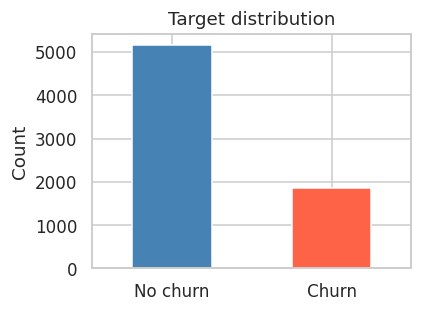

In [6]:
churn_rate = df[TARGET_COL].mean()
print(f'Churn rate: {churn_rate:.1%}  |  Majority class accuracy: {max(churn_rate, 1-churn_rate):.1%}')

fig, ax = plt.subplots(figsize=(4, 3))
df[TARGET_COL].value_counts().rename({0: 'No churn', 1: 'Churn'}).plot.bar(
    ax=ax, color=['steelblue', 'tomato']
)
ax.set_title('Target distribution')
ax.set_xlabel('')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Numeric feature distributions by churn

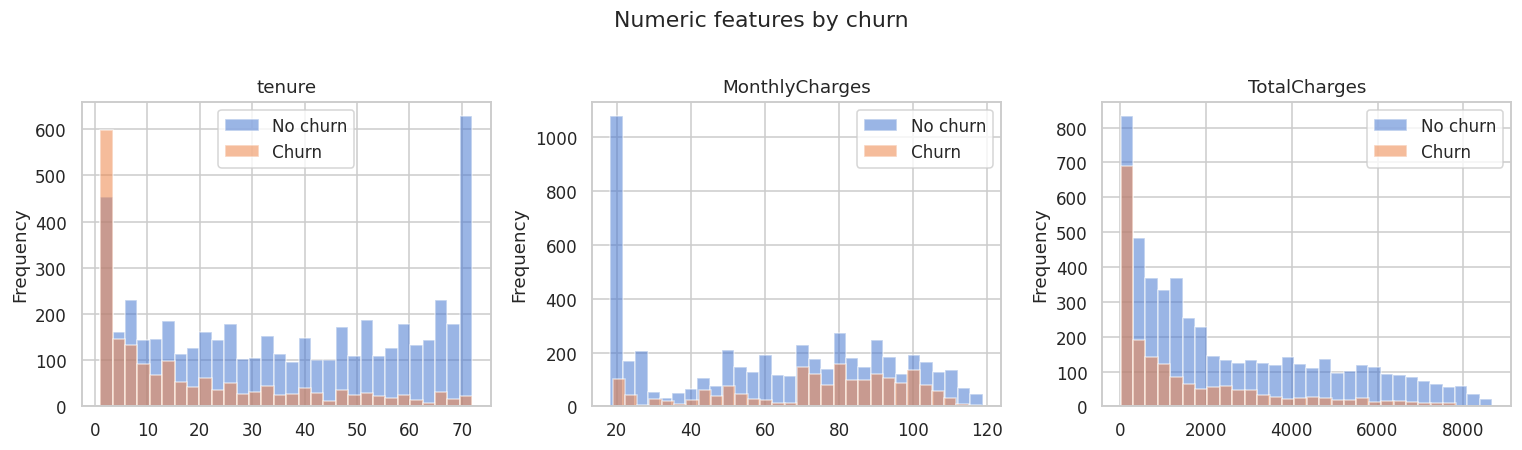

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby(TARGET_COL)[col]:
        grp.plot.hist(ax=ax, alpha=0.55, bins=30, label='Churn' if label else 'No churn')
    ax.set_title(col)
    ax.legend()
plt.suptitle('Numeric features by churn', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- `tenure`: churned customers skew towards low tenure (early-life dissatisfaction).
- `MonthlyCharges`: churned customers pay more on average — likely Fiber + Month-to-month plans.
- `TotalCharges`: correlated with tenure; churners cluster low.

## 5. Categorical features — churn rates

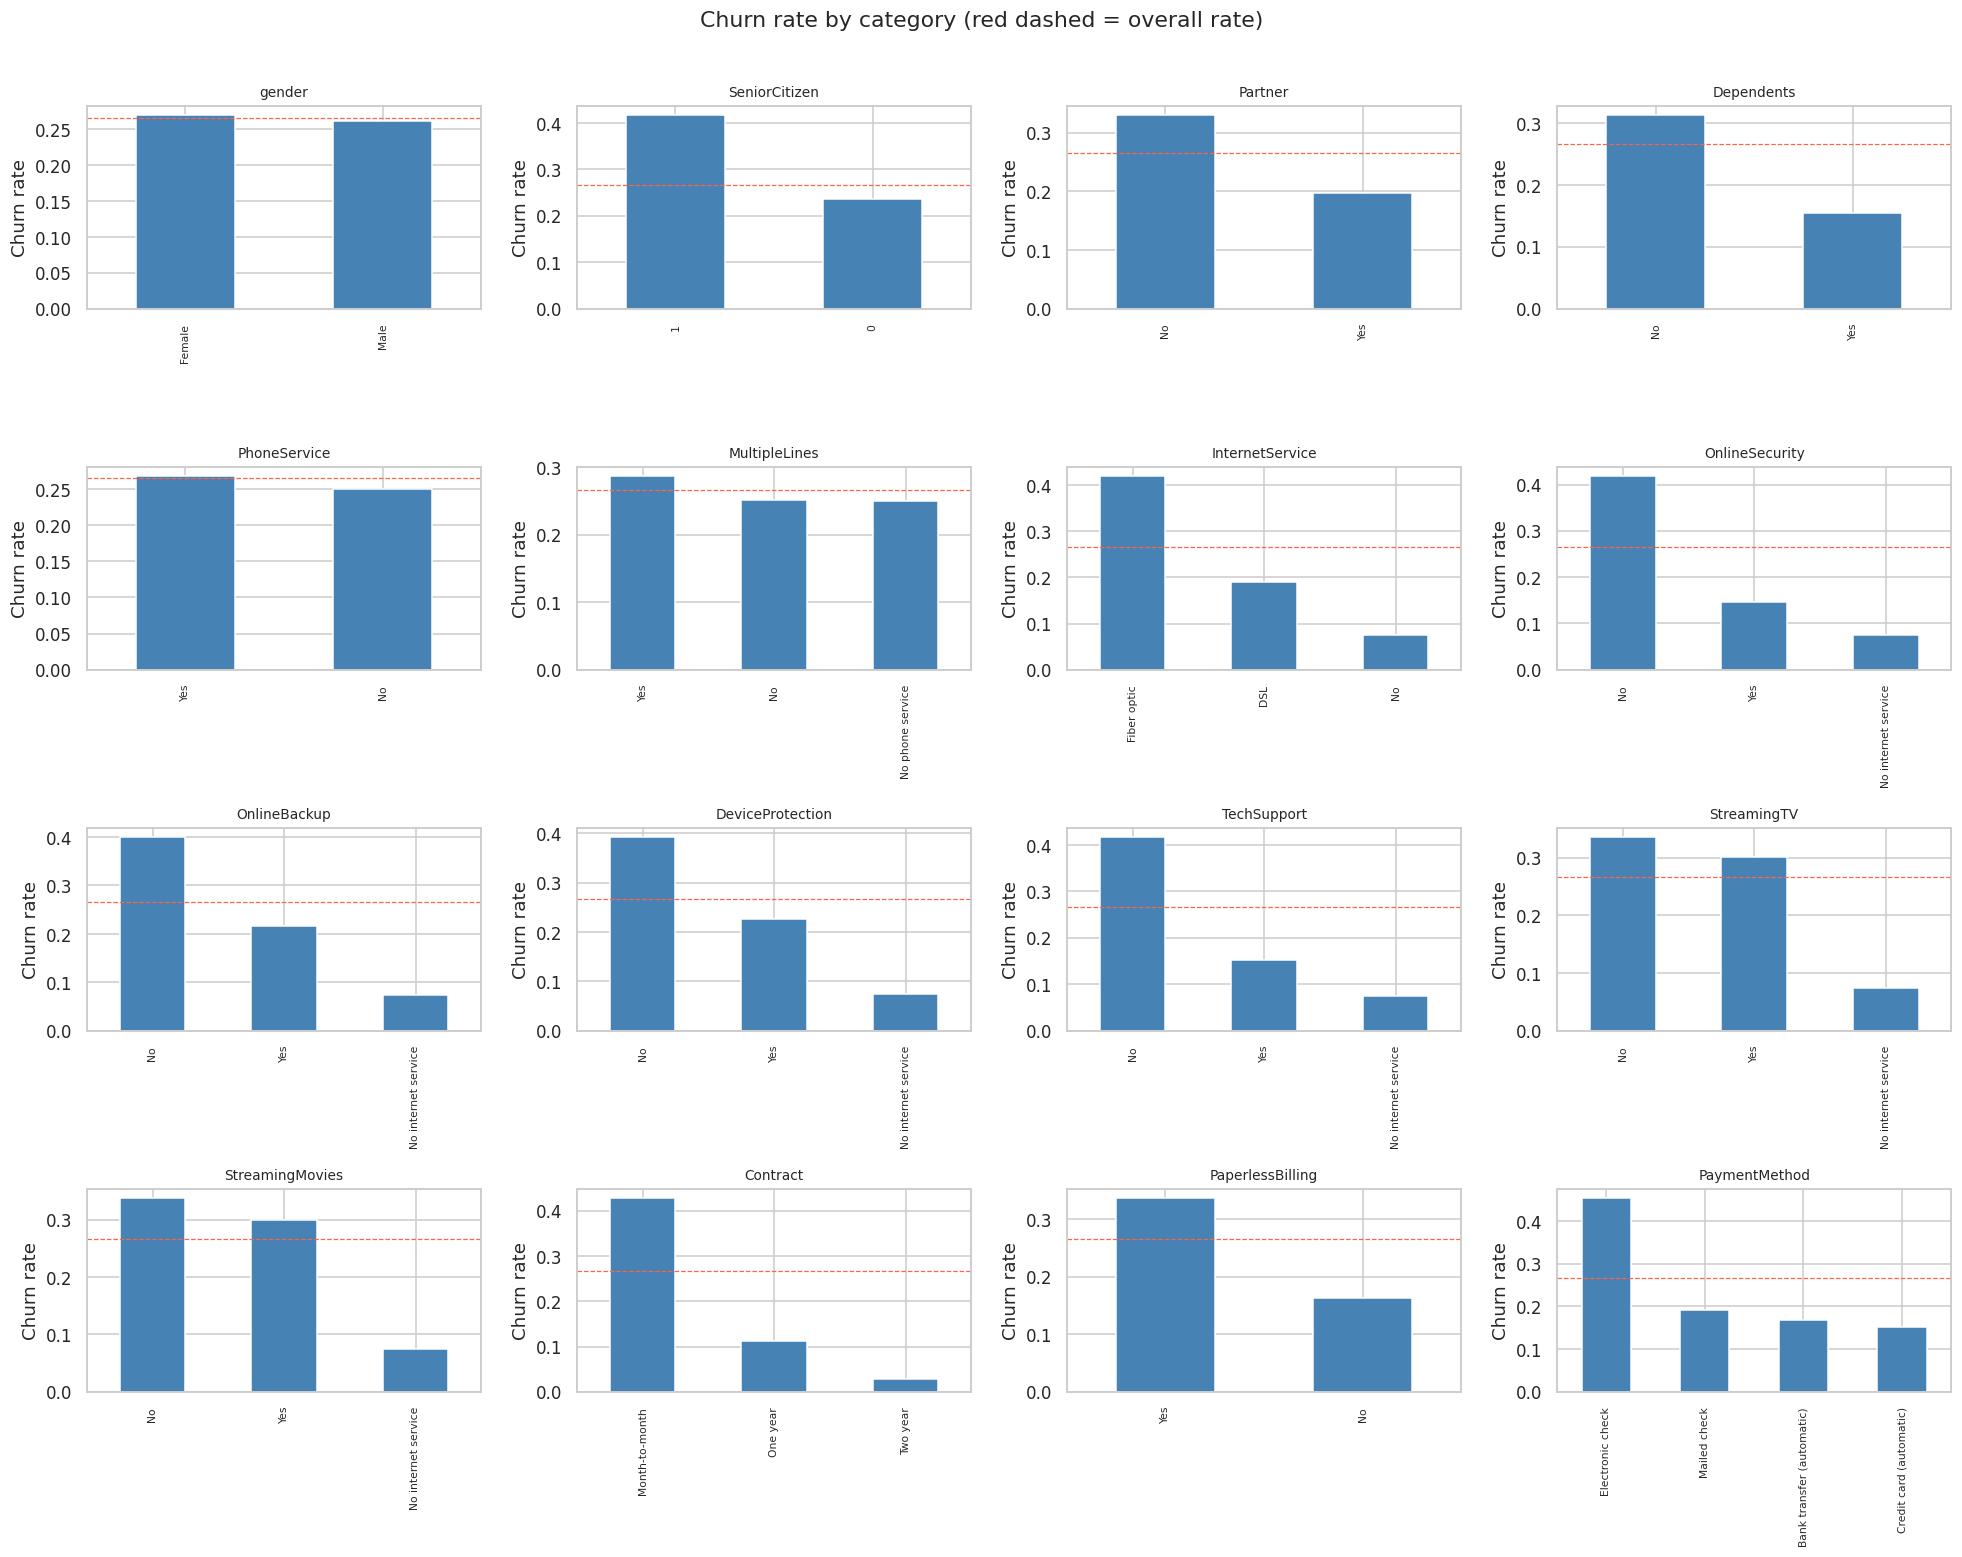

In [8]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    rates = df.groupby(col)[TARGET_COL].mean().sort_values(ascending=False)
    rates.plot.bar(ax=ax, color='steelblue')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Churn rate')
    ax.tick_params(axis='x', labelsize=7)
    ax.axhline(churn_rate, linestyle='--', color='tomato', linewidth=0.8)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Churn rate by category (red dashed = overall rate)', y=1.01)
plt.tight_layout()
plt.show()

**Key signals:**
- `Contract`: Month-to-month churns at ~43%, Two year at ~3% — the strongest single predictor.
- `InternetService`: Fiber optic users churn at ~42% vs DSL ~19%.
- `OnlineSecurity` / `TechSupport`: customers without add-ons churn at ~2x the rate.
- `PaymentMethod`: Electronic check users churn ~45% — correlated with Month-to-month.
- `gender`: near-identical churn rates — not a useful predictor.

## 6. Correlation matrix (numerics)

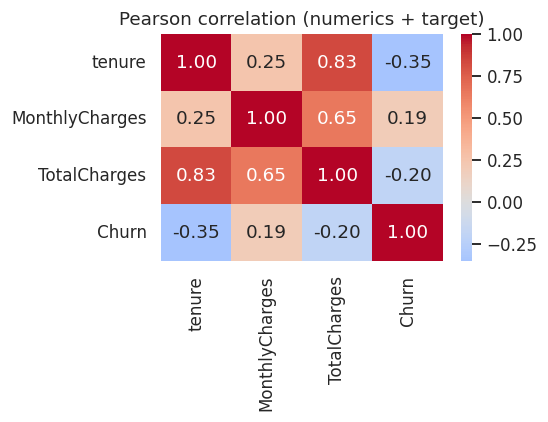

In [9]:
corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pearson correlation (numerics + target)')
plt.tight_layout()
plt.show()

**Note:** `TotalCharges` is highly correlated with `tenure` (r≈0.83). Multicollinearity affects LogReg coefficients; tree models handle it natively. We keep all three features.

## 7. Leakage check

In [10]:
from scipy.stats import pointbiserialr

results = []
for col in num_cols:
    r, p = pointbiserialr(df[TARGET_COL], df[col])
    results.append({'feature': col, 'r': round(r, 3), 'p': round(p, 4)})

pd.DataFrame(results).sort_values('r', key=abs, ascending=False)

,feature,r,p
0,tenure,-0.354,0.0
2,TotalCharges,-0.199,0.0
1,MonthlyCharges,0.193,0.0


In [11]:
print('All columns:')
for c in df.columns:
    print(' ', c)

All columns:
  customerID
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  MultipleLines
  InternetService
  OnlineSecurity
  OnlineBackup
  DeviceProtection
  TechSupport
  StreamingTV
  StreamingMovies
  Contract
  PaperlessBilling
  PaymentMethod
  MonthlyCharges
  TotalCharges
  Churn


No leakage detected. There are no post-hoc features (e.g. days_since_cancellation). `Contract` is a strong predictor but a legitimate business attribute captured before churn.

## 8. Senior citizen deep-dive (bias signal)

In [12]:
senior = df.groupby('SeniorCitizen')[TARGET_COL].agg(['mean', 'count']).rename(
    columns={'mean': 'churn_rate', 'count': 'n'}
)
senior['churn_rate'] = senior['churn_rate'].round(3)
senior.index = senior.index.map({0: 'Non-senior', 1: 'Senior'})
senior

,churn_rate,n
SeniorCitizen,,
Non-senior,0.237,5890
Senior,0.417,1142


Senior citizens churn at a meaningfully higher rate (~42% vs ~24%). This will be reported in the model card bias analysis.

## 9. Univariate predictive power summary

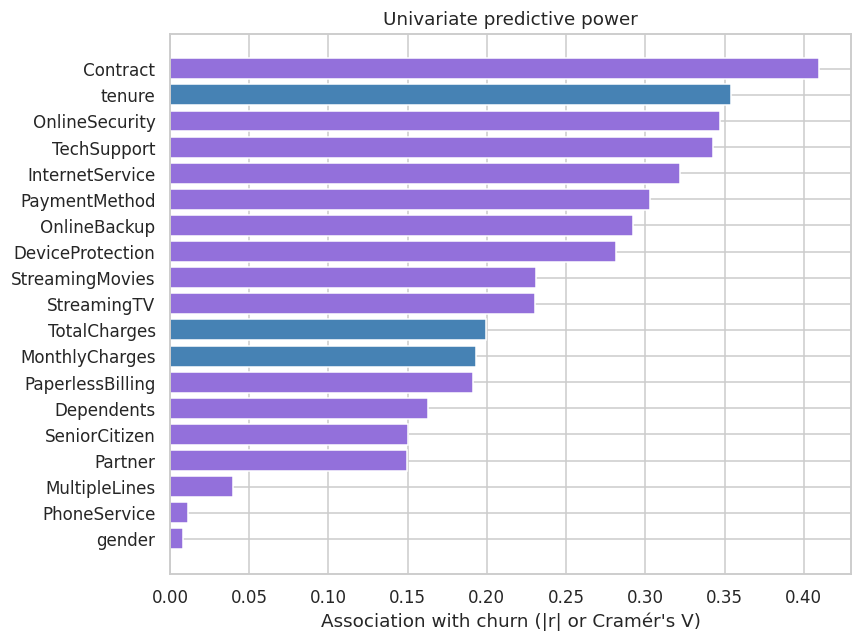

,feature,type,assoc
16,Contract,categorical,0.409560
0,tenure,numeric,0.354049
10,OnlineSecurity,categorical,0.346992
13,TechSupport,categorical,0.342506
9,InternetService,categorical,0.321909
18,PaymentMethod,categorical,0.302960
11,OnlineBackup,categorical,0.291902
12,DeviceProtection,categorical,0.281159
15,StreamingMovies,categorical,0.230702
14,StreamingTV,categorical,0.230143


In [13]:
from scipy.stats import chi2_contingency, pointbiserialr


def cramers_v(col):
    ct = pd.crosstab(df[col], df[TARGET_COL])
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))


rows = []
for col in num_cols:
    r, _ = pointbiserialr(df[TARGET_COL], df[col])
    rows.append({'feature': col, 'type': 'numeric', 'assoc': abs(r)})

for col in cat_cols:
    rows.append({'feature': col, 'type': 'categorical', 'assoc': cramers_v(col)})

summary = pd.DataFrame(rows).sort_values('assoc', ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue' if t == 'numeric' else 'mediumpurple' for t in summary['type']]
ax.barh(summary['feature'], summary['assoc'], color=colors)
ax.set_xlabel("Association with churn (|r| or Cramér's V)")
ax.set_title('Univariate predictive power')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

summary

---
## 10. Data readiness verdict

| Dimension | Status | Notes |
|---|---|---|
| **Volume** | GREEN | 7,032 rows after cleaning — sufficient for 5-fold CV and baseline comparison |
| **Label quality** | GREEN | Binary, ~26.6% positive — moderate class imbalance; use PR-AUC as primary metric |
| **Missingness** | GREEN | 11 rows dropped (TotalCharges whitespace for tenure=0); no other missing values |
| **Leakage** | GREEN | No post-hoc features; Contract is a strong predictor but a legitimate business attribute |
| **Feature quality** | YELLOW | TotalCharges ≈ tenure×MonthlyCharges (multicollinear); keep all three, note in model card |
| **Drift expectations** | YELLOW | Point-in-time snapshot; no temporal ordering; real deployment needs date column for drift monitoring |
| **Bias signals** | YELLOW | SeniorCitizen churn rate ~42% vs ~24%; gender has no predictive signal — report slices in model card |

**Floor to beat:**  
A stratified dummy achieves ~26.6% PR-AUC by definition (equal to the base rate). LogReg and GBM baselines will set the real floor. **The MLP must beat the best baseline on PR-AUC to justify deployment.**